In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path

# Cargar datos — desde carpeta processed relativa a Notebooks
DATA_DIR = Path("..") / "Data" / "processed"
train = pd.read_csv(DATA_DIR / "train.csv")
val   = pd.read_csv(DATA_DIR / "val.csv")
test  = pd.read_csv(DATA_DIR / "test.csv")

print(f"Train: {len(train):,} | Val: {len(val):,} | Test: {len(test):,}")
print(f"Columnas: {list(train.columns)}")

Train: 70,000 | Val: 15,000 | Test: 15,000
Columnas: ['user_id', 'book_id', 'review_id', 'rating', 'review_text', 'date_added', 'date_updated', 'read_at', 'started_at', 'n_votes', 'n_comments', 'has_spoiler']


In [2]:
# TF-IDF con 20,000 tokens
print("Entrenando TF-IDF...")

tfidf = TfidfVectorizer(
    max_features=20_000,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train = tfidf.fit_transform(train["review_text"]).toarray()
X_val   = tfidf.transform(val["review_text"]).toarray()
X_test  = tfidf.transform(test["review_text"]).toarray()

# Labels — rating (0-4 en vez de 1-5)
y_train_rating = (train["rating"] - 1).values
y_val_rating   = (val["rating"] - 1).values
y_test_rating  = (test["rating"] - 1).values

# Labels — spoiler
y_train_spoiler = train["has_spoiler"].astype(float).values
y_val_spoiler   = val["has_spoiler"].astype(float).values
y_test_spoiler  = test["has_spoiler"].astype(float).values

print(f"Shape X_train: {X_train.shape}")
print(f"Shape X_val:   {X_val.shape}")
print(f"Shape X_test:  {X_test.shape}")
print(f"\nVocabulario TF-IDF: {len(tfidf.vocabulary_):,} tokens")

Entrenando TF-IDF...
Shape X_train: (70000, 20000)
Shape X_val:   (15000, 20000)
Shape X_test:  (15000, 20000)

Vocabulario TF-IDF: 20,000 tokens
Shape X_train: (70000, 20000)
Shape X_val:   (15000, 20000)
Shape X_test:  (15000, 20000)

Vocabulario TF-IDF: 20,000 tokens


In [3]:
# Arquitectura MLP con 3 cabezas de salida
class MLPMultitask(nn.Module):
    def __init__(self, input_dim=20_000):
        super().__init__()
        
        # Encoder compartido
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        
        # Cabeza Tarea 1 — Rating (5 clases)
        self.head_rating = nn.Linear(128, 5)
        
        # Cabeza Tarea 2 — Spoiler (binaria)
        self.head_spoiler = nn.Linear(128, 1)
    
    def forward(self, x):
        features = self.encoder(x)
        rating  = self.head_rating(features)
        spoiler = self.head_spoiler(features)
        return rating, spoiler

# Verificar arquitectura
model = MLPMultitask()
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parámetros: {total_params:,}")

# Usar MPS si está disponible (Apple Silicon)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")
model = model.to(device)

MLPMultitask(
  (encoder): Sequential(
    (0): Linear(in_features=20000, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
  )
  (head_rating): Linear(in_features=128, out_features=5, bias=True)
  (head_spoiler): Linear(in_features=128, out_features=1, bias=True)
)

Total parámetros: 5,153,926
Device: cpu


In [4]:
# Dataset personalizado
class GoodreadsDataset(Dataset):
    def __init__(self, X, y_rating, y_spoiler):
        self.X        = torch.tensor(X, dtype=torch.float32)
        self.y_rating  = torch.tensor(y_rating, dtype=torch.long)
        self.y_spoiler = torch.tensor(y_spoiler, dtype=torch.float32)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y_rating[idx], self.y_spoiler[idx]

# Crear datasets
train_dataset = GoodreadsDataset(X_train, y_train_rating, y_train_spoiler)
val_dataset   = GoodreadsDataset(X_val,   y_val_rating,   y_val_spoiler)
test_dataset  = GoodreadsDataset(X_test,  y_test_rating,  y_test_spoiler)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=256, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False)

print(f"Batches en train: {len(train_loader)}")
print(f"Batches en val:   {len(val_loader)}")
print(f"Batches en test:  {len(test_loader)}")

Batches en train: 274
Batches en val:   59
Batches en test:  59


In [5]:
from sklearn.metrics import f1_score

# Configuración de entrenamiento
criterion_rating  = nn.CrossEntropyLoss()
criterion_spoiler = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Pesos de la loss multitarea
alpha = 0.7  # rating
beta  = 0.3  # spoiler

EPOCHS = 10
history = {"train_loss": [], "val_loss": [], "val_acc_rating": [], "val_f1_spoiler": []}

print("Iniciando entrenamiento MLP...\n")

for epoch in range(EPOCHS):
    # ── Train ──
    model.train()
    train_loss = 0
    for X_b, y_rat, y_spo in train_loader:
        X_b   = X_b.to(device)
        y_rat = y_rat.to(device)
        y_spo = y_spo.to(device)
        
        optimizer.zero_grad()
        out_rating, out_spoiler = model(X_b)
        
        loss = alpha * criterion_rating(out_rating, y_rat) + \
               beta  * criterion_spoiler(out_spoiler.squeeze(), y_spo)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    # ── Validación ──
    model.eval()
    val_loss = 0
    preds_rating, preds_spoiler = [], []
    true_rating,  true_spoiler  = [], []
    
    with torch.no_grad():
        for X_b, y_rat, y_spo in val_loader:
            X_b   = X_b.to(device)
            y_rat = y_rat.to(device)
            y_spo = y_spo.to(device)
            
            out_rating, out_spoiler = model(X_b)
            loss = alpha * criterion_rating(out_rating, y_rat) + \
                   beta  * criterion_spoiler(out_spoiler.squeeze(), y_spo)
            val_loss += loss.item()
            
            preds_rating.extend(out_rating.argmax(dim=1).cpu().numpy())
            preds_spoiler.extend((out_spoiler.squeeze() > 0).cpu().numpy())
            true_rating.extend(y_rat.cpu().numpy())
            true_spoiler.extend(y_spo.cpu().numpy())
    
    # Métricas
    acc_rating  = np.mean(np.array(preds_rating) == np.array(true_rating))
    f1_spoiler  = f1_score(true_spoiler, preds_spoiler, zero_division=0)
    
    history["train_loss"].append(train_loss / len(train_loader))
    history["val_loss"].append(val_loss / len(val_loader))
    history["val_acc_rating"].append(acc_rating)
    history["val_f1_spoiler"].append(f1_spoiler)
    
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Train Loss: {train_loss/len(train_loader):.4f} | "
          f"Val Loss: {val_loss/len(val_loader):.4f} | "
          f"Acc Rating: {acc_rating:.4f} | "
          f"F1 Spoiler: {f1_spoiler:.4f}")

print("\nEntrenamiento completado ✓")

Iniciando entrenamiento MLP...

Epoch 01/10 | Train Loss: 0.9430 | Val Loss: 0.7945 | Acc Rating: 0.5171 | F1 Spoiler: 0.0000
Epoch 01/10 | Train Loss: 0.9430 | Val Loss: 0.7945 | Acc Rating: 0.5171 | F1 Spoiler: 0.0000
Epoch 02/10 | Train Loss: 0.7398 | Val Loss: 0.8046 | Acc Rating: 0.5071 | F1 Spoiler: 0.0000
Epoch 02/10 | Train Loss: 0.7398 | Val Loss: 0.8046 | Acc Rating: 0.5071 | F1 Spoiler: 0.0000
Epoch 03/10 | Train Loss: 0.6679 | Val Loss: 0.8413 | Acc Rating: 0.4989 | F1 Spoiler: 0.0000
Epoch 03/10 | Train Loss: 0.6679 | Val Loss: 0.8413 | Acc Rating: 0.4989 | F1 Spoiler: 0.0000
Epoch 04/10 | Train Loss: 0.5812 | Val Loss: 0.9085 | Acc Rating: 0.4797 | F1 Spoiler: 0.0000
Epoch 04/10 | Train Loss: 0.5812 | Val Loss: 0.9085 | Acc Rating: 0.4797 | F1 Spoiler: 0.0000
Epoch 05/10 | Train Loss: 0.4769 | Val Loss: 1.0340 | Acc Rating: 0.4752 | F1 Spoiler: 0.0000
Epoch 05/10 | Train Loss: 0.4769 | Val Loss: 1.0340 | Acc Rating: 0.4752 | F1 Spoiler: 0.0000
Epoch 06/10 | Train Loss: 0.

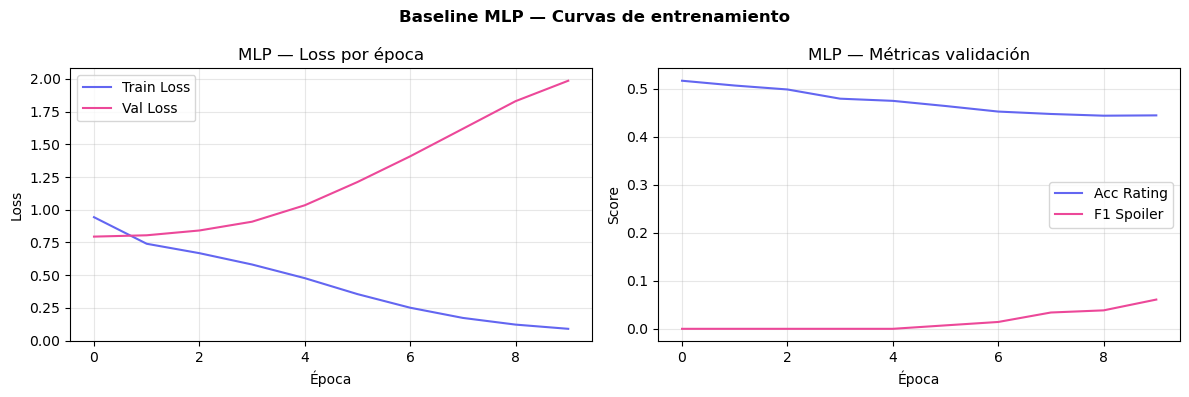

=== RESULTADOS FINALES MLP (Test) ===
Acc Rating:  0.4555
MAE Rating:  0.7528
F1 Spoiler:  0.0950

Observación: overfitting claro → justifica BiLSTM y DistilBERT


In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, mean_absolute_error

# Curvas de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="Train Loss", color="#6366f1")
axes[0].plot(history["val_loss"],   label="Val Loss",   color="#ec4899")
axes[0].set_title("MLP — Loss por época")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history["val_acc_rating"],  label="Acc Rating",  color="#6366f1")
axes[1].plot(history["val_f1_spoiler"],  label="F1 Spoiler",  color="#ec4899")
axes[1].set_title("MLP — Métricas validación")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Score")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Baseline MLP — Curvas de entrenamiento", fontweight="bold")
plt.tight_layout()
plt.savefig("mlp_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# Evaluación en test
model.eval()
preds_rating, preds_spoiler = [], []
true_rating,  true_spoiler  = [], []

with torch.no_grad():
    for X_b, y_rat, y_spo in test_loader:
        X_b = X_b.to(device)
        out_rating, out_spoiler = model(X_b)
        preds_rating.extend(out_rating.argmax(dim=1).cpu().numpy())
        preds_spoiler.extend((out_spoiler.squeeze() > 0).cpu().numpy())
        true_rating.extend(y_rat.numpy())
        true_spoiler.extend(y_spo.numpy())

preds_rating = np.array(preds_rating)
true_rating  = np.array(true_rating)

acc  = np.mean(preds_rating == true_rating)
mae  = mean_absolute_error(true_rating, preds_rating)
f1   = f1_score(true_spoiler, preds_spoiler, zero_division=0)

print("=== RESULTADOS FINALES MLP (Test) ===")
print(f"Acc Rating:  {acc:.4f}")
print(f"MAE Rating:  {mae:.4f}")
print(f"F1 Spoiler:  {f1:.4f}")
print(f"\nObservación: overfitting claro → justifica BiLSTM y DistilBERT")

In [7]:
# Guardar modelo y resultados
torch.save(model.state_dict(), "mlp_model.pt")

resultados_mlp = {
    "modelo": "MLP + TF-IDF",
    "acc_rating": round(acc, 4),
    "mae_rating": round(mae, 4),
    "f1_spoiler": round(f1, 4)
}

import json
with open("resultados_mlp.json", "w") as f:
    json.dump(resultados_mlp, f, indent=2)

print("Modelo guardado: mlp_model.pt ✓")
print("Resultados guardados: resultados_mlp.json ✓")
print("\nResumen MLP:")
for k, v in resultados_mlp.items():
    print(f"  {k}: {v}")

Modelo guardado: mlp_model.pt ✓
Resultados guardados: resultados_mlp.json ✓

Resumen MLP:
  modelo: MLP + TF-IDF
  acc_rating: 0.4555
  mae_rating: 0.7528
  f1_spoiler: 0.095
